<a href="https://colab.research.google.com/github/Samruddhi1595/malaria_detection/blob/main/notebooks/malaria_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Malaria Detection using Deep Learning

This notebook performs:
1. Dataset loading
2. Data preprocessing
3. Data visualization



In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [16]:
!unzip cell_images.zip

Streaming output truncated to the last 5000 lines.
 extracting: cell_images/Uninfected/C236ThinF_IMG_20151127_102428_cell_118.png  
 extracting: cell_images/Uninfected/C236ThinF_IMG_20151127_102428_cell_126.png  
 extracting: cell_images/Uninfected/C236ThinF_IMG_20151127_102428_cell_134.png  
 extracting: cell_images/Uninfected/C236ThinF_IMG_20151127_102428_cell_141.png  
 extracting: cell_images/Uninfected/C236ThinF_IMG_20151127_102428_cell_168.png  
 extracting: cell_images/Uninfected/C236ThinF_IMG_20151127_102428_cell_175.png  
 extracting: cell_images/Uninfected/C236ThinF_IMG_20151127_102428_cell_183.png  
 extracting: cell_images/Uninfected/C236ThinF_IMG_20151127_102428_cell_221.png  
 extracting: cell_images/Uninfected/C236ThinF_IMG_20151127_102428_cell_222.png  
 extracting: cell_images/Uninfected/C236ThinF_IMG_20151127_102428_cell_87.png  
 extracting: cell_images/Uninfected/C236ThinF_IMG_20151127_102428_cell_91.png  
 extracting: cell_images/Uninfected/C236ThinF_IMG_20151127_1

In [17]:
dataset_path = "cell_images"

print(os.listdir(dataset_path))

['Parasitized', 'Uninfected']


In [18]:
parasitized_count = len(os.listdir("cell_images/Parasitized"))
uninfected_count = len(os.listdir("cell_images/Uninfected"))

print("Parasitized Images:", parasitized_count)
print("Uninfected Images:", uninfected_count)

Parasitized Images: 13780
Uninfected Images: 13780


Text(0.5, 1.0, 'Parasitized Cell')

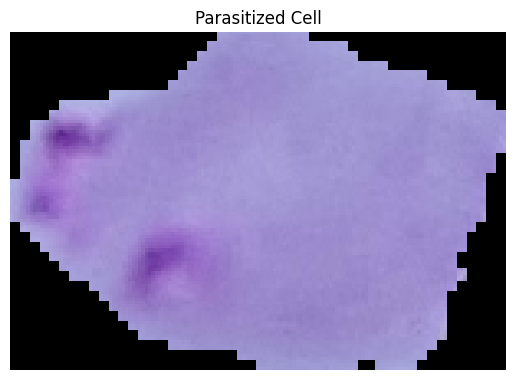

In [19]:
import random

parasitized_path = "cell_images/Parasitized"
img_name = random.choice(os.listdir(parasitized_path))

img = cv2.imread(os.path.join(parasitized_path, img_name))

plt.imshow(img)
plt.axis("off")
plt.title("Parasitized Cell")

Text(0.5, 0.98, 'Sample Parasitized Cells')

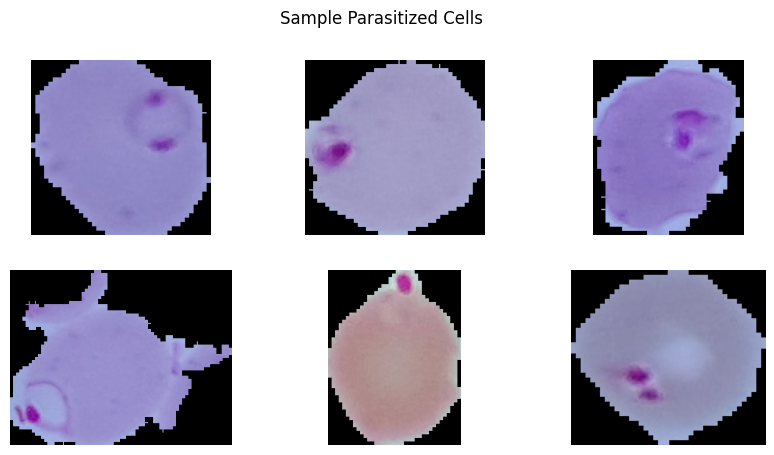

In [20]:
plt.figure(figsize=(10,5))

for i in range(6):
    img_name = random.choice(os.listdir(parasitized_path))
    img = cv2.imread(os.path.join(parasitized_path, img_name))

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.suptitle("Sample Parasitized Cells")

Text(0.5, 0.98, 'Sample Parasitized Cells')

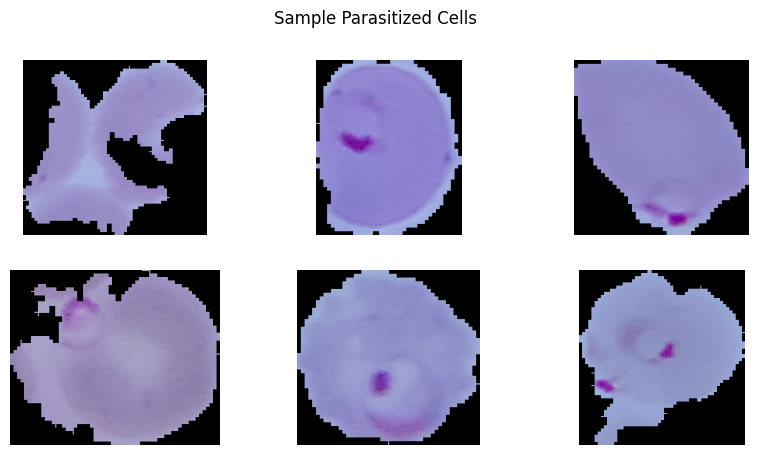

In [21]:
plt.figure(figsize=(10,5))

for i in range(6):
    img_name = random.choice(os.listdir(parasitized_path))
    img = cv2.imread(os.path.join(parasitized_path, img_name))

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.suptitle("Sample Parasitized Cells")

Text(0, 0.5, 'Number of Images')

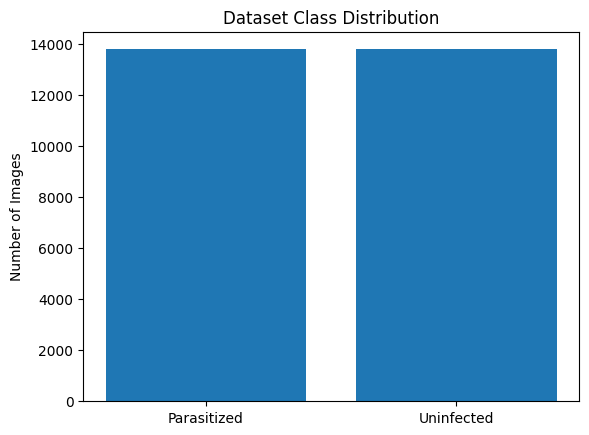

In [22]:
labels = ["Parasitized", "Uninfected"]
counts = [parasitized_count, uninfected_count]

plt.bar(labels, counts)
plt.title("Dataset Class Distribution")
plt.ylabel("Number of Images")

(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

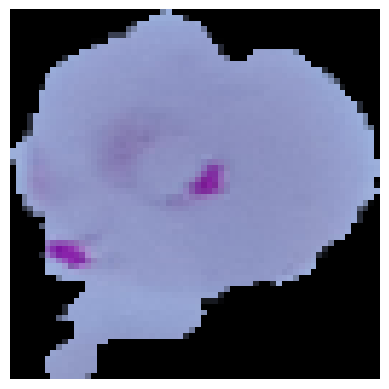

In [23]:
img_size = 64

sample_img = cv2.imread(os.path.join(parasitized_path, img_name))
resized_img = cv2.resize(sample_img, (img_size, img_size))

plt.imshow(resized_img)
plt.axis("off")

In [24]:
data = []
labels = []

for category in ["Parasitized", "Uninfected"]:
    path = os.path.join("cell_images", category)
    label = 0 if category == "Parasitized" else 1

    for img in os.listdir(path)[:500]:  # limit for faster training
        img_path = os.path.join(path, img)
        img_array = cv2.imread(img_path)
        img_array = cv2.resize(img_array, (64,64))

        data.append(img_array)
        labels.append(label)

data = np.array(data)/255.0
labels = np.array(labels)

In [25]:
!wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip

--2026-03-07 13:58:57--  https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
Resolving data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)... 3.173.161.53, 3.173.161.80, 3.173.161.10, ...
Connecting to data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)|3.173.161.53|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 353452851 (337M) [application/zip]
Saving to: ‘cell_images.zip.1’

cell_images.zip.1   100%[===================>] 337.08M   130MB/s    in 2.6s    

2026-03-07 13:59:00 (130 MB/s) - ‘cell_images.zip.1’ saved [353452851/353452851]

